In [1]:
from pathlib import Path
import json
from dataclasses import asdict
from itertools import product

from rabl.machine_learning.tuner import GridSearchConfig, TrialResult, count_grid_combinations, run_grid_search, test_best_model
from rabl.machine_learning.lstm_pipeline import (
    build_datasets,
    train_with_fallback,
    cleanup_cuda,
    save_forecast_profiles_pdf,
)

In [2]:
lookback_datasets = {
    #12: Path("../outputs/datasets/scaled_split/lstm_merged_batches_0001-0002_k12_minmax_train0.70_val0.15_test0.15.h5"),
    8:  Path("../outputs/datasets/scaled_split/lstm_merged_batches_0001-0002_k8_minmax_train0.70_val0.15_test0.15.h5"),
    #4:  Path("../outputs/datasets/scaled_split/lstm_merged_batches_0001-0002_k4_minmax_train0.70_val0.15_test0.15.h5"),
}

for lb, p in lookback_datasets.items():
    print(f"lookback={lb} exists={p.exists()} path={p}")

lookback=8 exists=True path=..\outputs\datasets\scaled_split\lstm_merged_batches_0001-0002_k8_minmax_train0.70_val0.15_test0.15.h5


In [7]:
out_dir = Path("../outputs/ml_results/hp_tuning/N2001/tuning_k8/")
out_dir.mkdir(parents=True, exist_ok=True)

config = GridSearchConfig(
    lookback_datasets=lookback_datasets,
    learning_rates=[1e-4, 1e-3],
    batch_sizes=[128, 256],
    n_lstm_values=[1, 2, 3],
    hidden_lstm_values=[256, 384],
    hidden_fc_values=[256],
    n_fc=1,
    epochs=50,
    seed=123,
    out_dir=out_dir,
    prefer_gpu=True,
    verbose=1,
    lstm_dropout=0.3,
    preload_train_to_device=True,
    early_stopping_patience=10,
    early_stopping_min_delta=1e-6,
    restore_best_weights=True,
    step_lr_step_size=30,
    step_lr_gamma=0.5,
)

print("out_dir:", config.out_dir)
print("Total trials:", count_grid_combinations(config))

out_dir: ..\outputs\ml_results\hp_tuning\N2001\tuning_k8
Total trials: 24


Total combinations: 24
[1/24] lookback=8, lr=0.0001, batch_size=128, n_lstm=1, hidden_lstm=256, hidden_fc=256
Using GPU: NVIDIA GeForce RTX 4060 Ti

Deterministic seed set to: 123
LSTMRegressor architecture:
  Input features: 14
  LSTM layers (1): hidden_size=256, dropout=0.3
  FC layers (1): [256]
  Output targets: 13



C:\Users\Logan\anaconda3\envs\pymola\Lib\site-packages\torch\nn\modules\rnn.py:83: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "
Preloading train batches: 21886batch [00:35, 616.03batch/s]


Preloaded 21886 training batches to cuda:0 in 35.53s.


Train 1/50: 100%|██████████████████████████████████████████| 21886/21886 [01:27<00:00, 250.26batch/s, loss=3.09076e-06]
Val 1/50: 4690batch [00:12, 380.35batch/s]


Epoch 1/50 - loss: 4.18382e-04 - val_loss: 8.87612e-06 - lr: 1.000e-04 - data_wait: 0.54s - h2d: 0.01s - compute: 71.91s - val_time: 12.33s - epoch_total: 84.79s - preloaded: True - preload_time: 35.53s - max_cuda_mem: 1580.18 MB - io_h5: 13.62s - io_cast: 0.32s - io_profiles: 1400 - io_samples: 2801400 - io_tput: 200894.33 samp/s - io_frac_of_data_wait: 2566.03%
Epoch 1/50 total_time_s: 84.79


...

Epoch 20/50 - loss: 1.30513e-05 - val_loss: 1.11204e-05 - lr: 1.000e-03 - data_wait: 0.32s - h2d: 0.00s - compute: 62.46s - val_time: 9.00s - epoch_total: 71.78s - preloaded: True - preload_time: 23.02s - max_cuda_mem: 1705.81 MB - io_h5: 0.00s - io_cast: 0.00s - io_profiles: 0 - io_samples: 0 - io_tput: 0.00 samp/s - io_frac_of_data_wait: 0.00%
Epoch 20/50 total_time_s: 71.78
Early stopping check: 8/10 epochs without validation improvement.


Train 21/50: 100%|█████████████████████████████████████████| 10943/10943 [01:08<00:00, 158.83batch/s, loss=1.02668e-05]
Val 21/50: 2345batch [00:09, 257.04batch/s]


Epoch 21/50 - loss: 1.31745e-05 - val_loss: 2.18319e-05 - lr: 1.000e-03 - data_wait: 0.32s - h2d: 0.00s - compute: 62.64s - val_time: 9.13s - epoch_total: 72.09s - preloaded: True - preload_time: 23.02s - max_cuda_mem: 1705.81 MB - io_h5: 0.00s - io_cast: 0.00s - io_profiles: 0 - io_samples: 0 - io_tput: 0.00 samp/s - io_frac_of_data_wait: 0.00%
Epoch 21/50 total_time_s: 72.09
Early stopping check: 9/10 epochs without validation improvement.


Train 22/50: 100%|█████████████████████████████████████████| 10943/10943 [01:08<00:00, 159.01batch/s, loss=1.14464e-05]
Val 22/50: 2345batch [00:09, 260.33batch/s]


Epoch 22/50 - loss: 1.27014e-05 - val_loss: 1.33568e-05 - lr: 1.000e-03 - data_wait: 0.32s - h2d: 0.00s - compute: 62.59s - val_time: 9.01s - epoch_total: 71.93s - preloaded: True - preload_time: 23.02s - max_cuda_mem: 1705.81 MB - io_h5: 0.00s - io_cast: 0.00s - io_profiles: 0 - io_samples: 0 - io_tput: 0.00 samp/s - io_frac_of_data_wait: 0.00%
Epoch 22/50 total_time_s: 71.93
Early stopping check: 10/10 epochs without validation improvement.
Early stopping triggered at epoch 22; best validation loss was 1.11351e-05 at epoch 12.
Restored best model weights from epoch 12.
Saved training curves to ..\outputs\ml_results\hp_tuning\N2001\tuning_k8\trial_0024_lb8_lr0.001_bs256_nl3_hl384_hf256\lstm_train_val_curve.png
Saved learning-rate curve to ..\outputs\ml_results\hp_tuning\N2001\tuning_k8\trial_0024_lb8_lr0.001_bs256_nl3_hl384_hf256\lstm_lr_curve.png

Timing summary (cumulative):
  preload_time: 23.02s
  train_data_wait_time: 7.32s
  train_h2d_time: 0.05s
  train_compute_time: 1398.19s
 

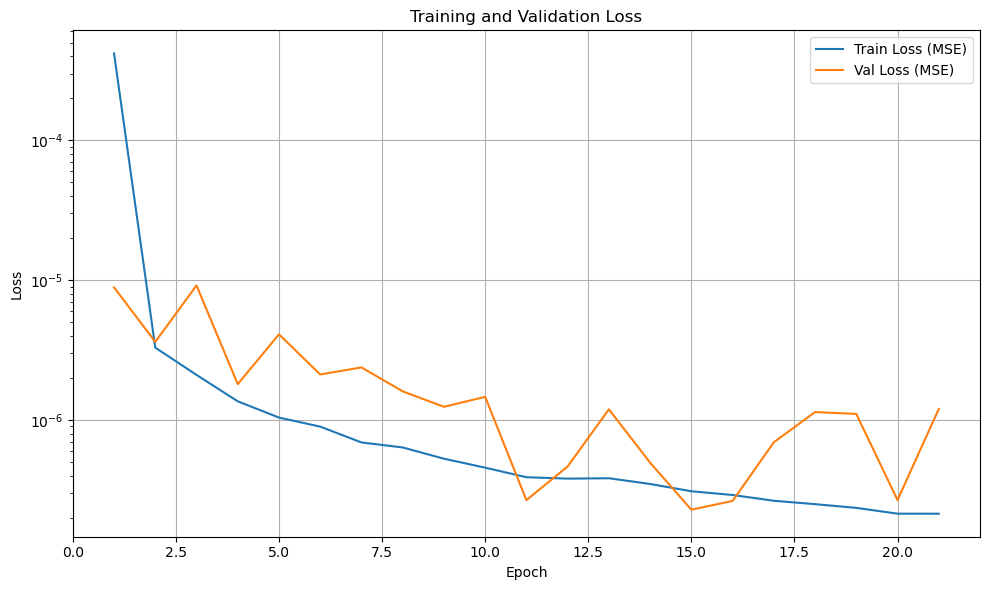

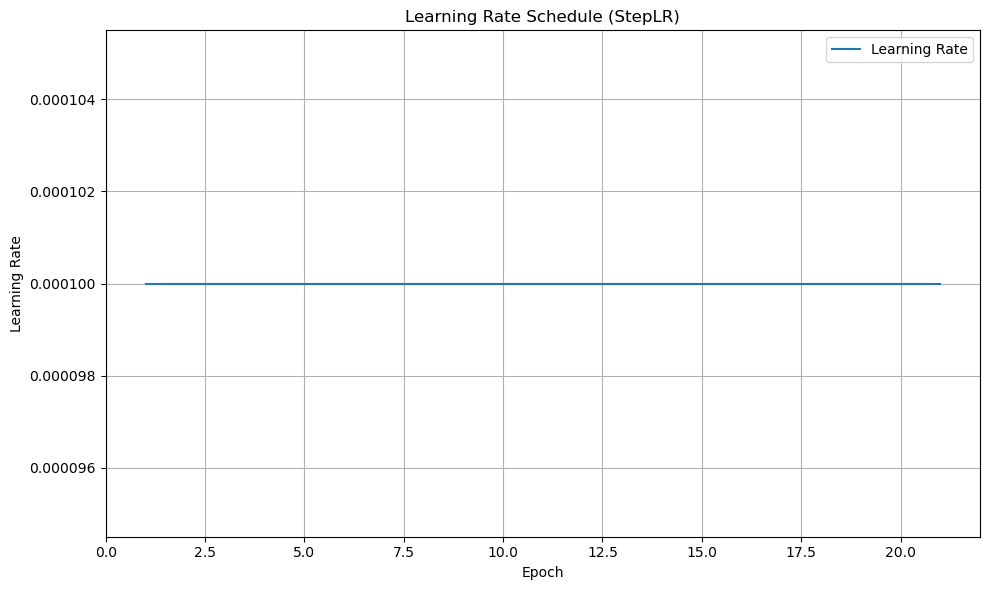

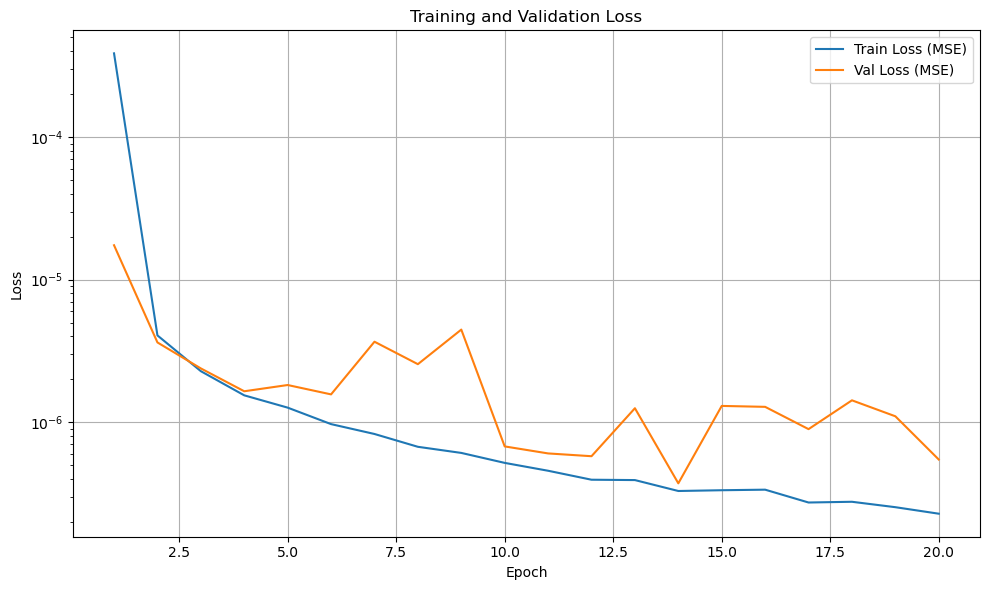

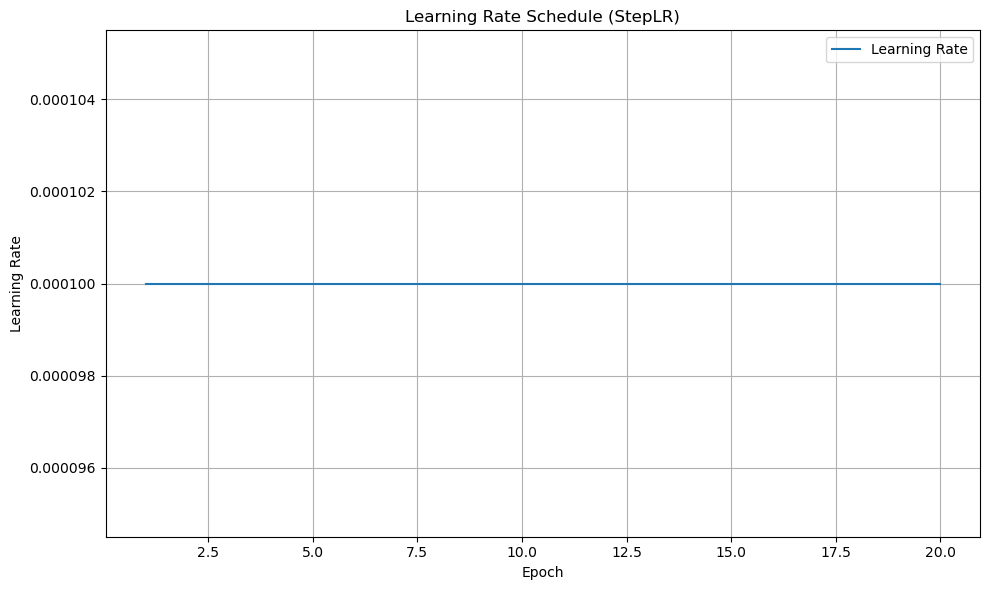

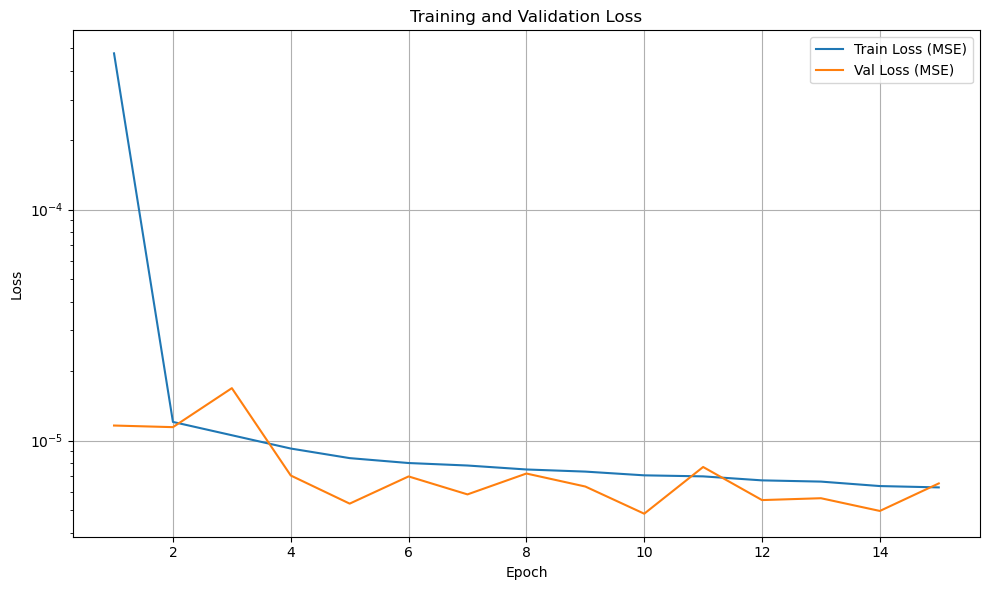

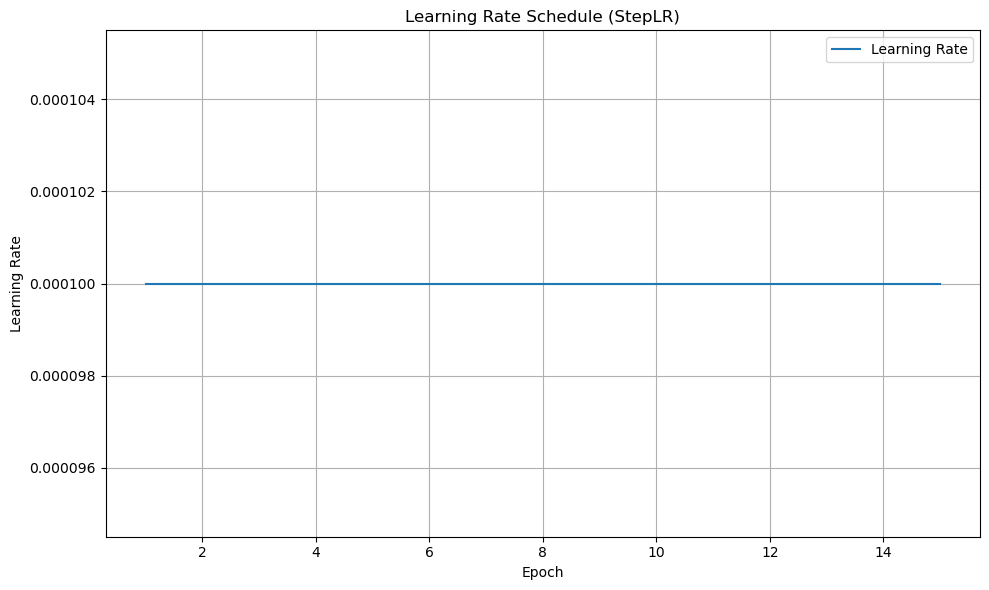

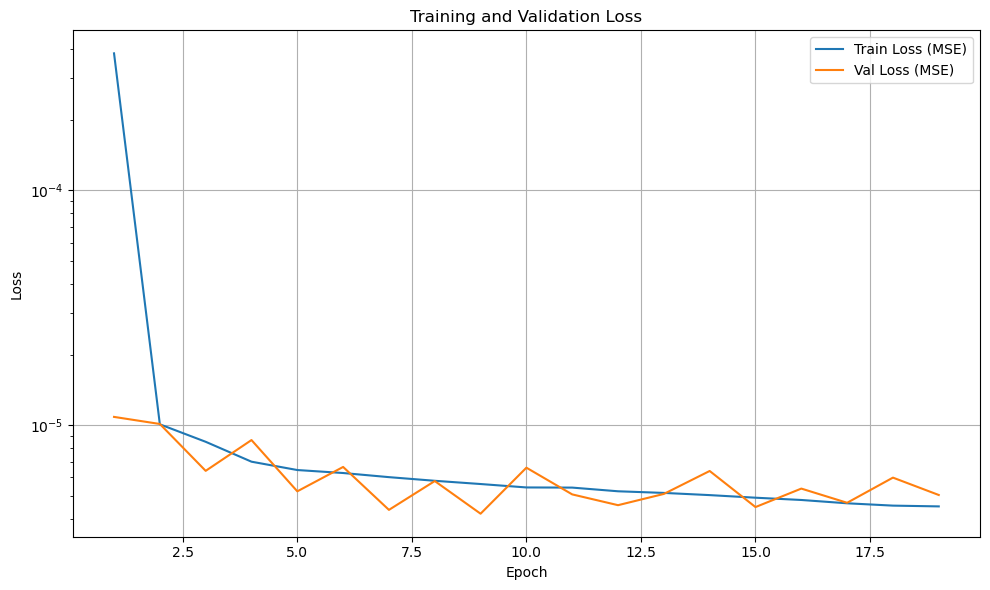

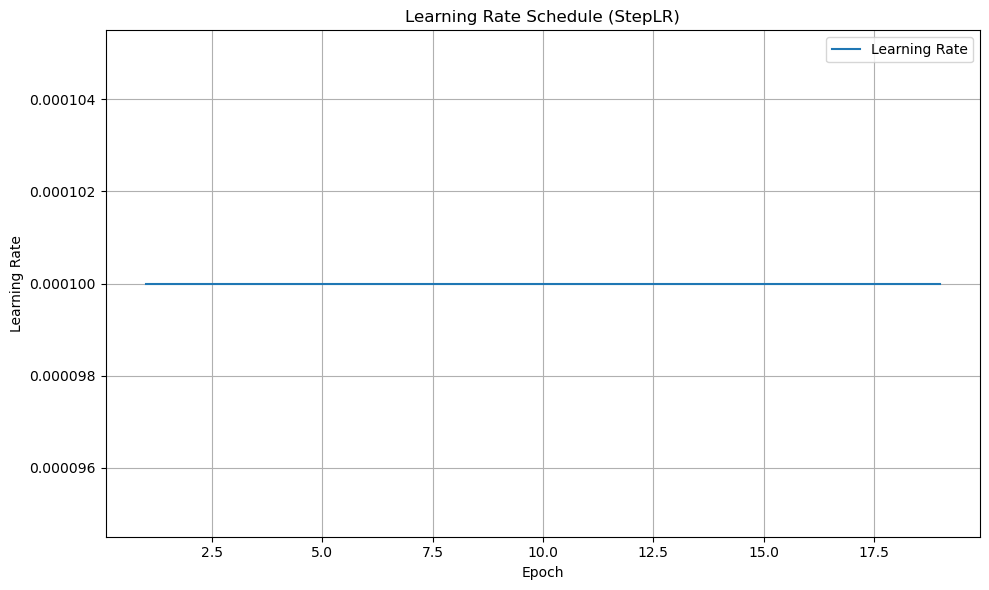

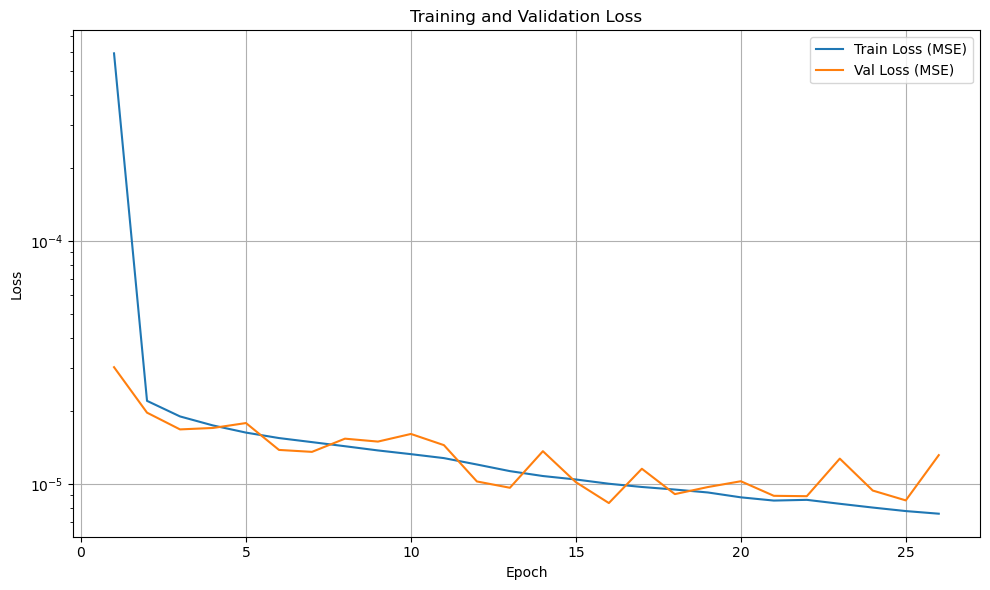

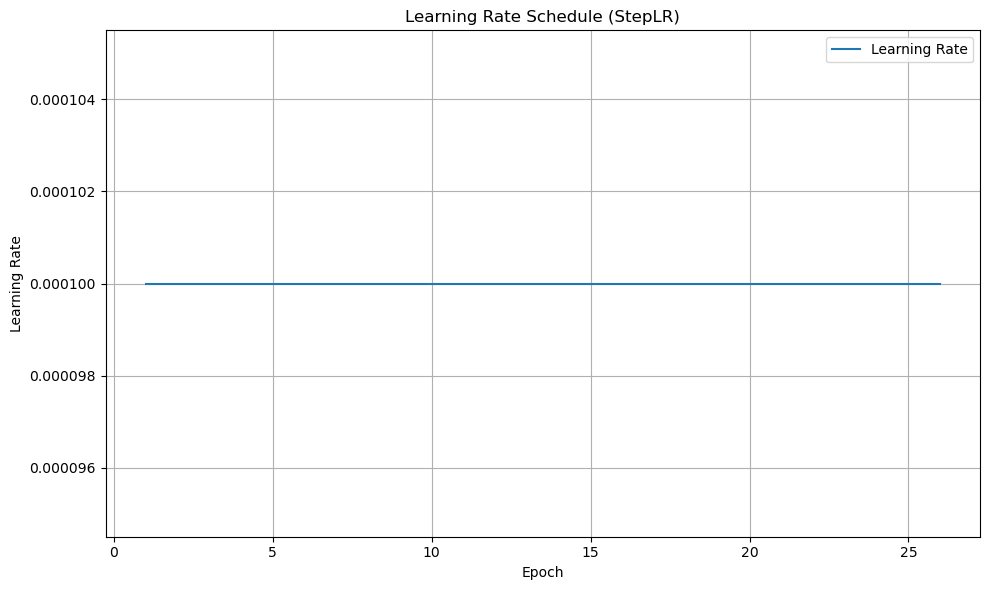

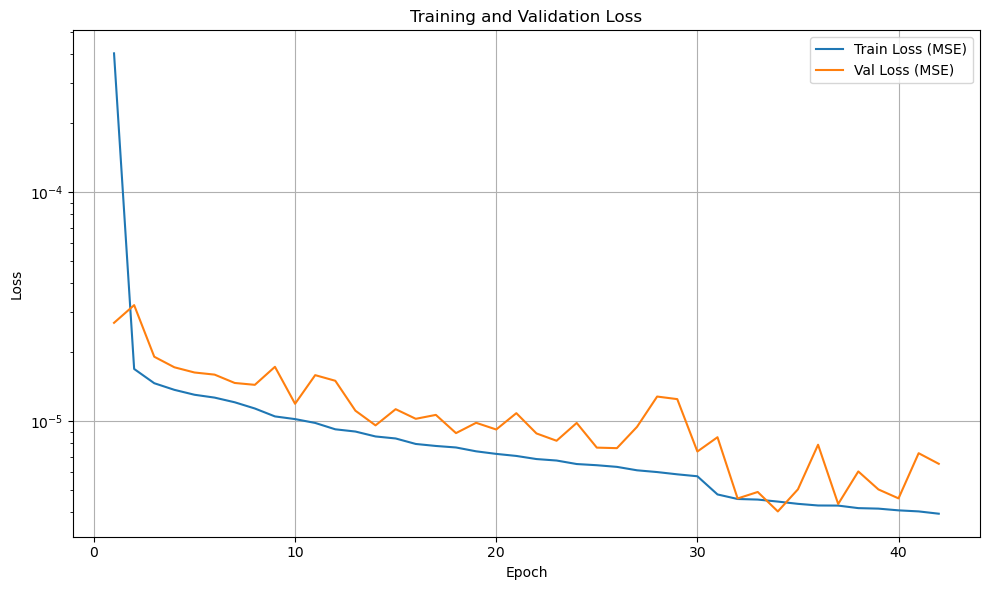

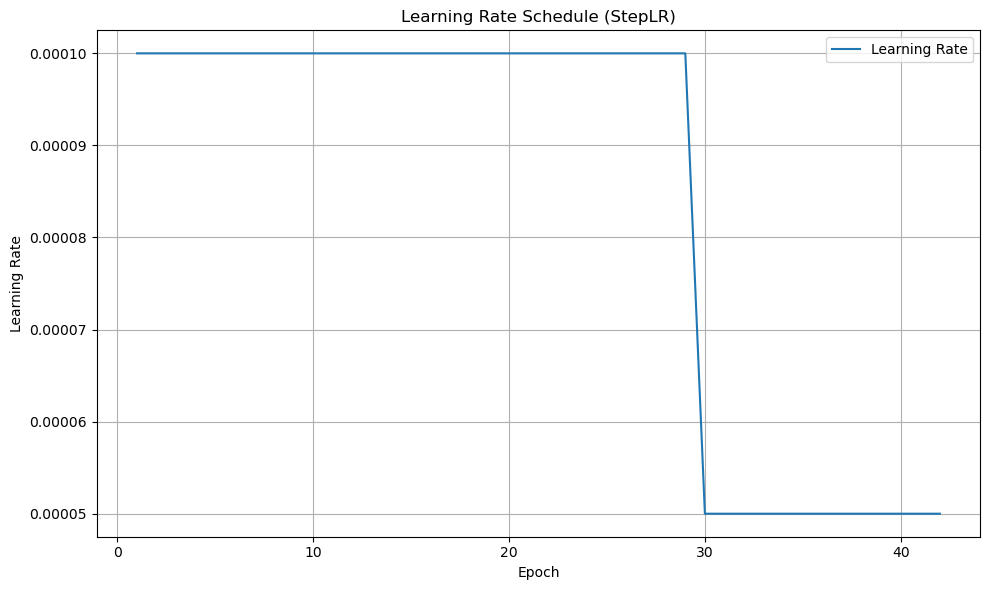

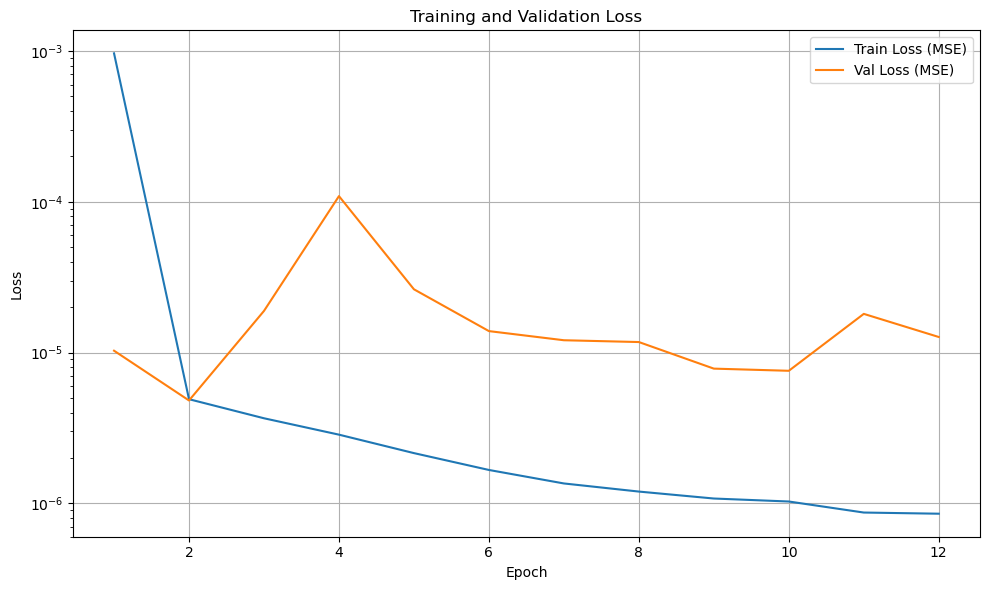

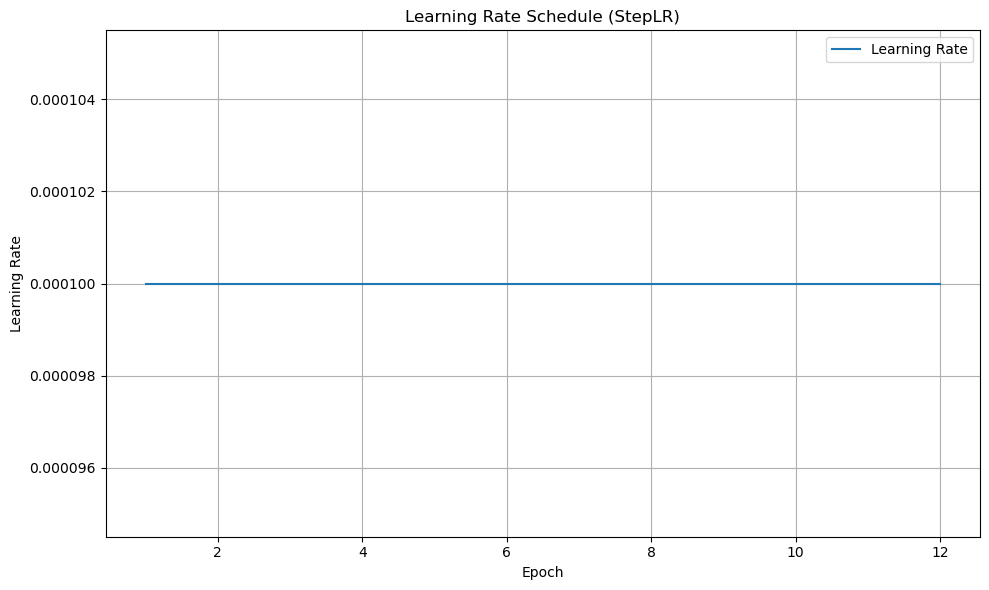

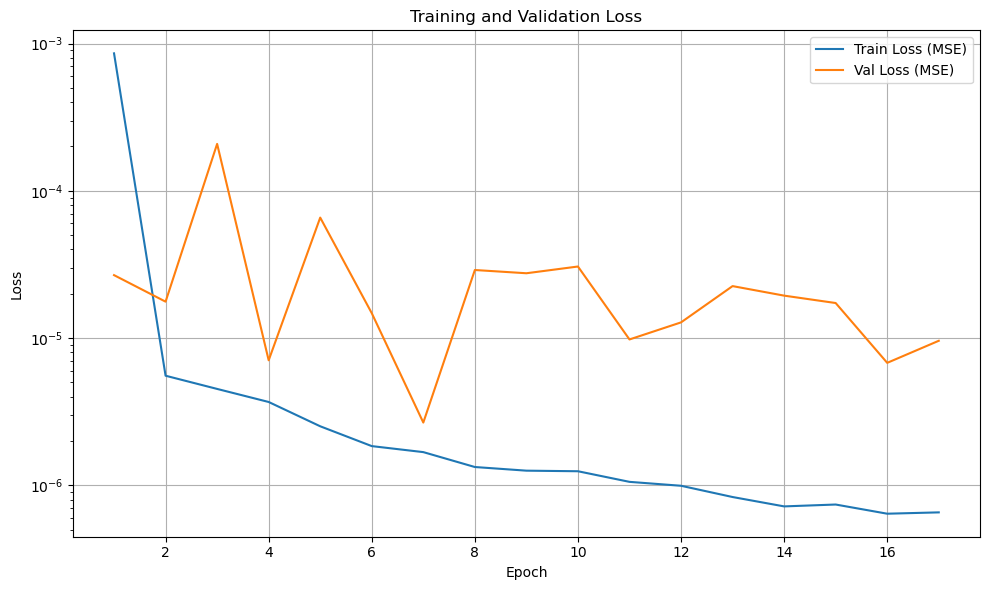

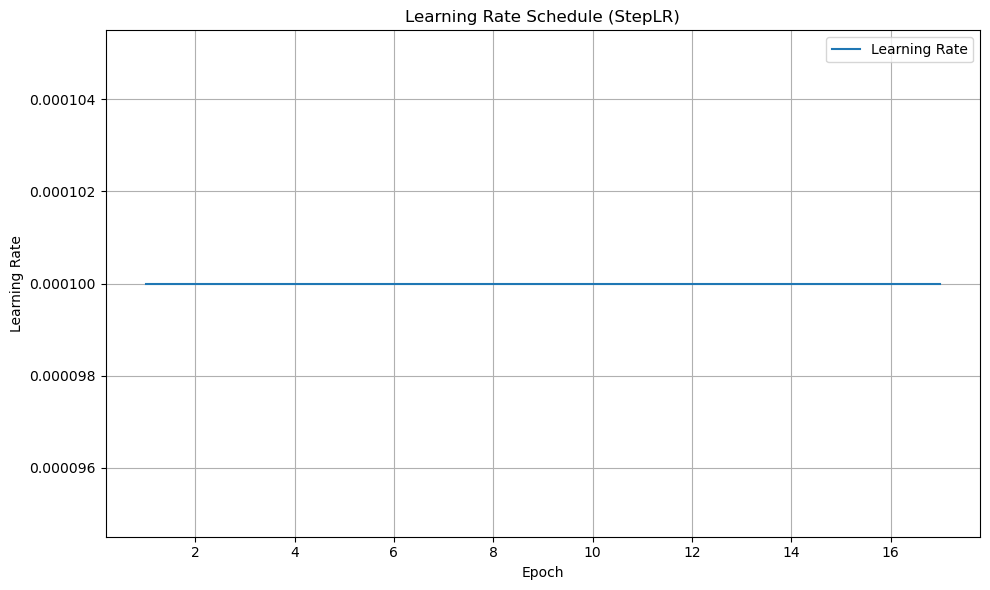

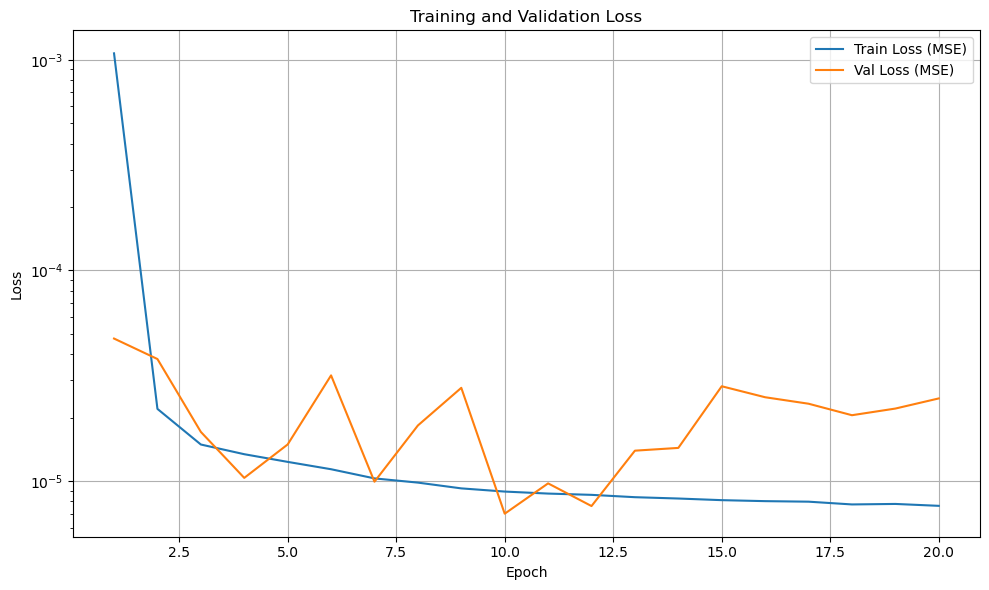

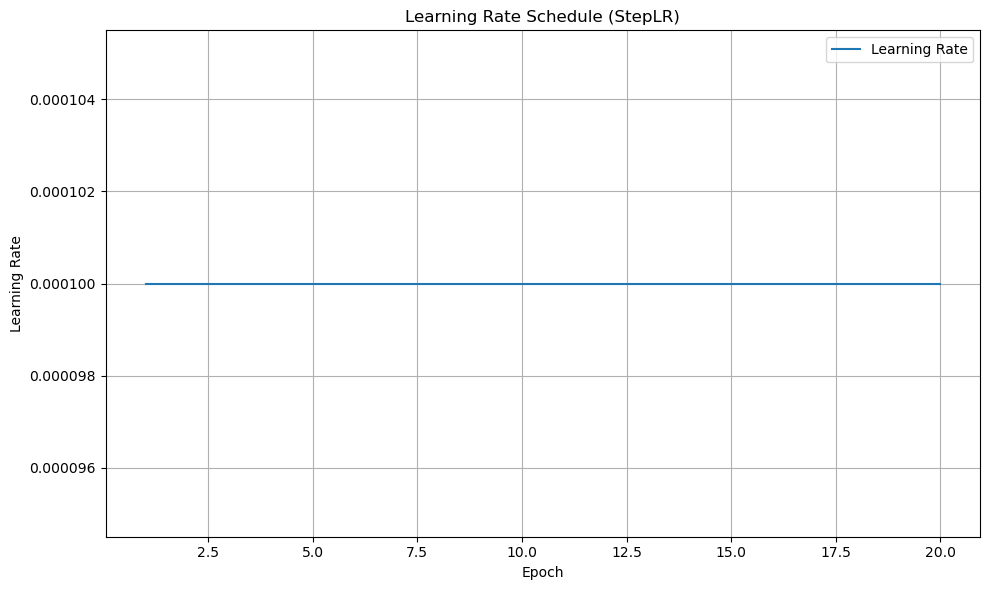

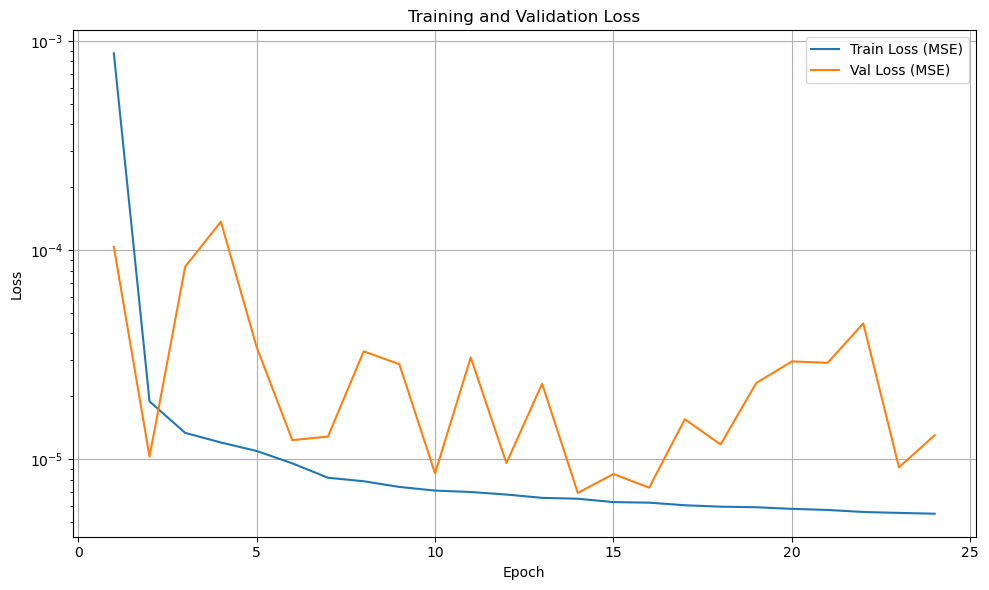

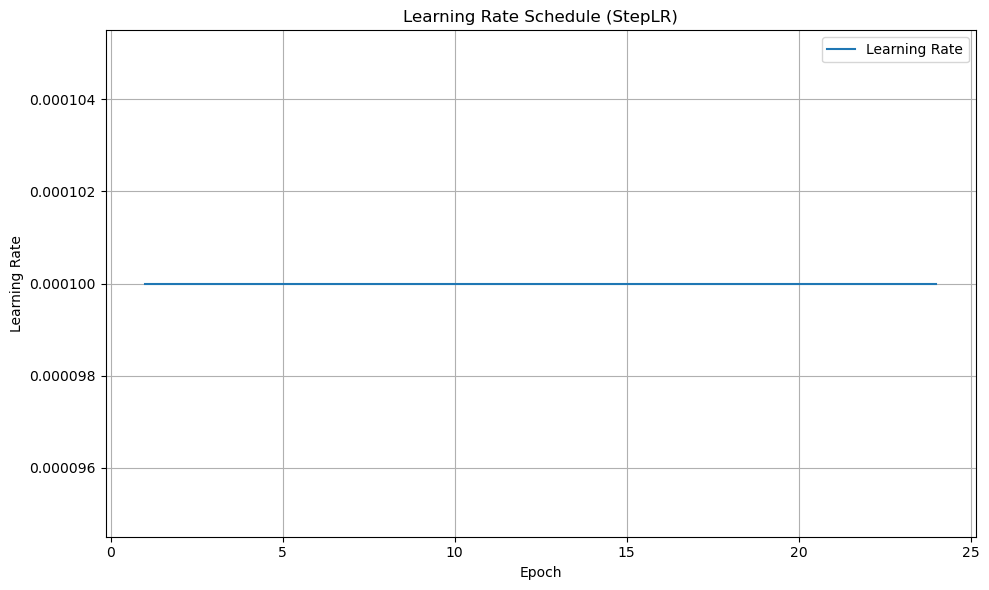

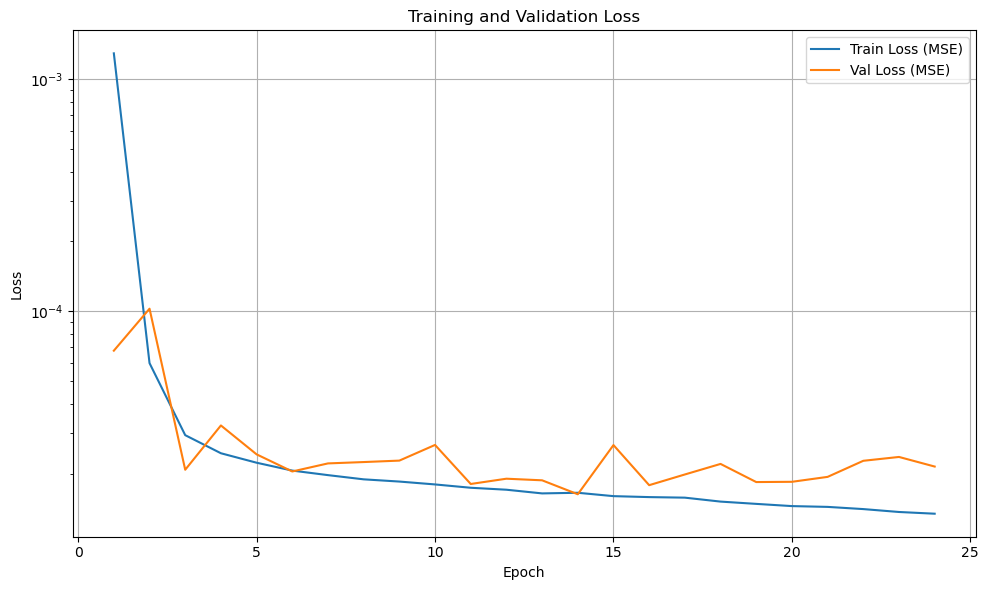

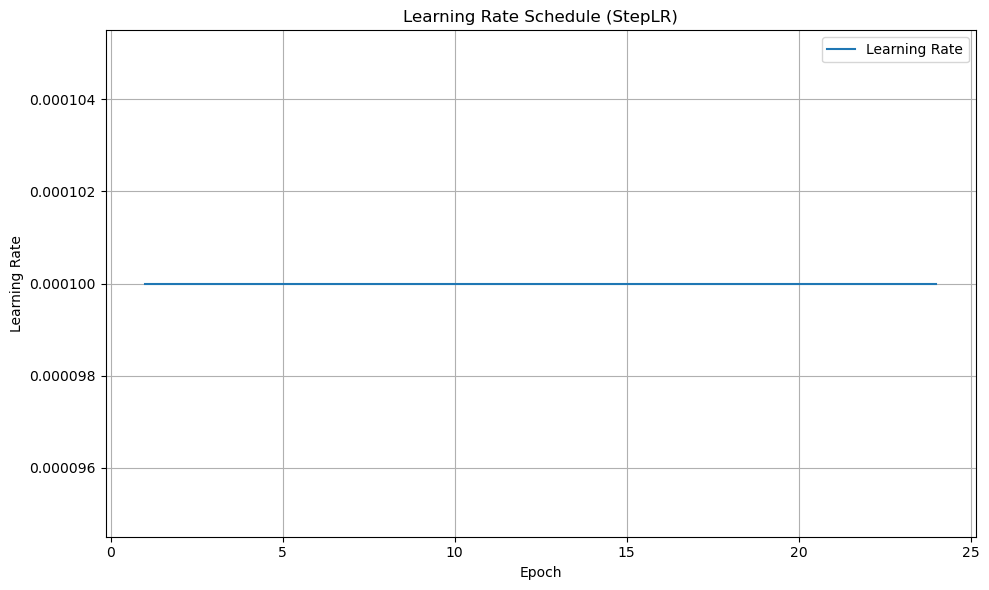

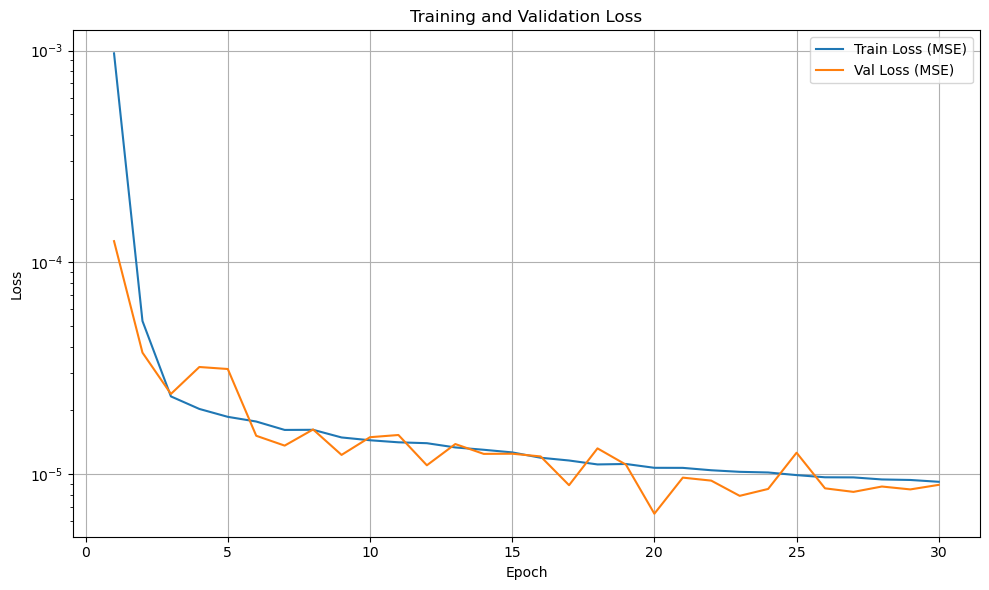

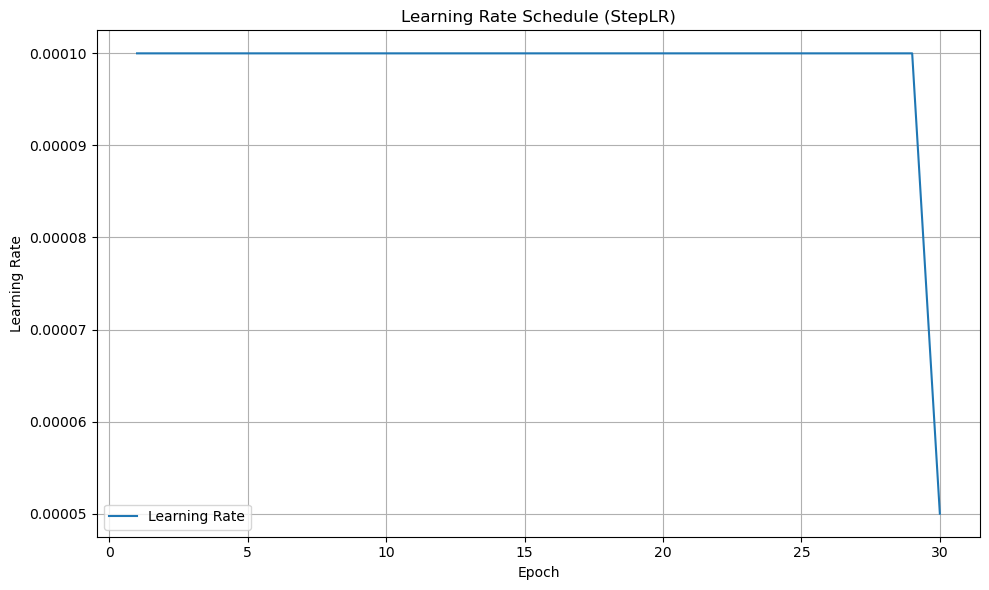

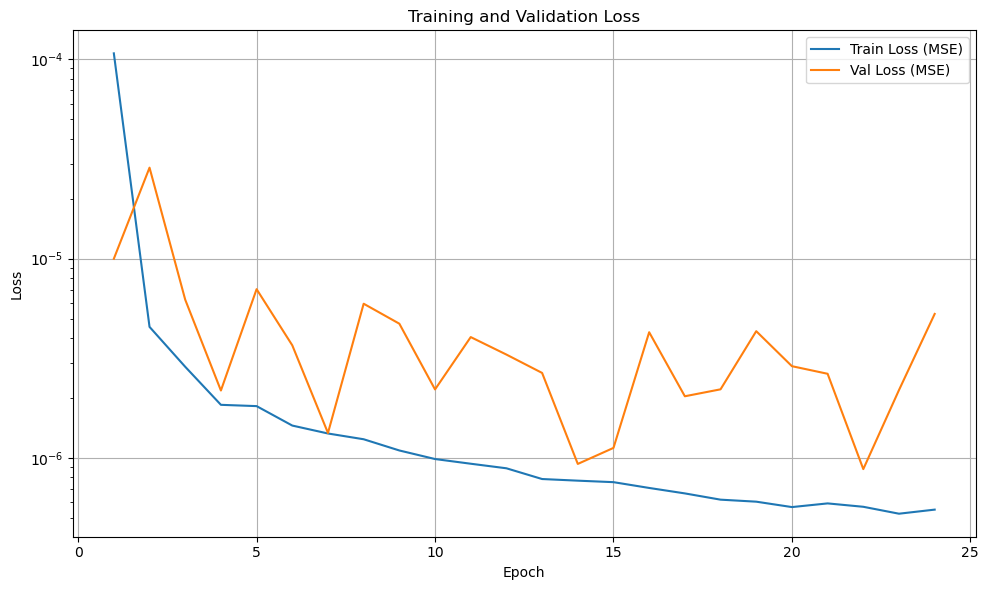

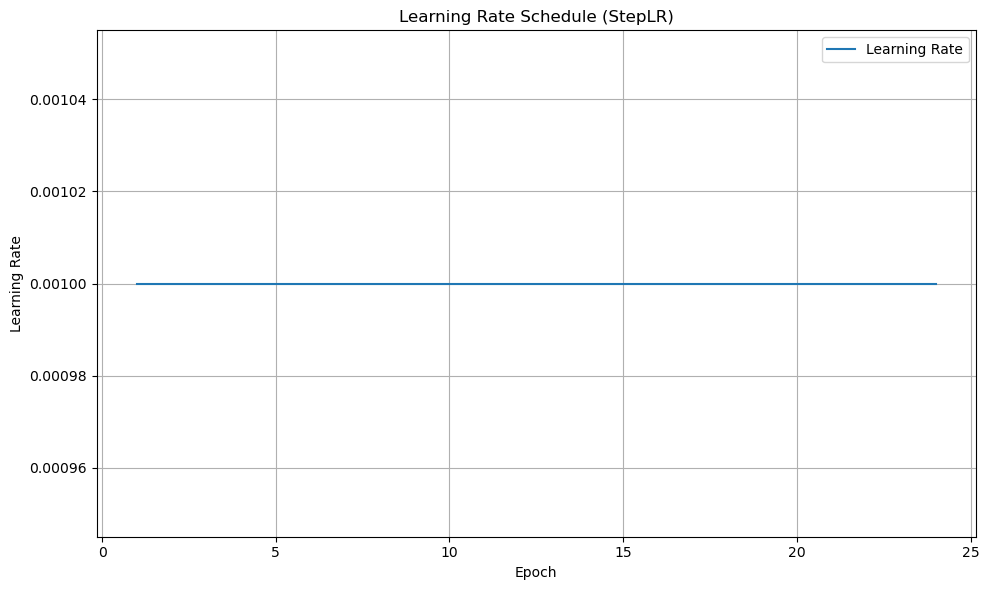

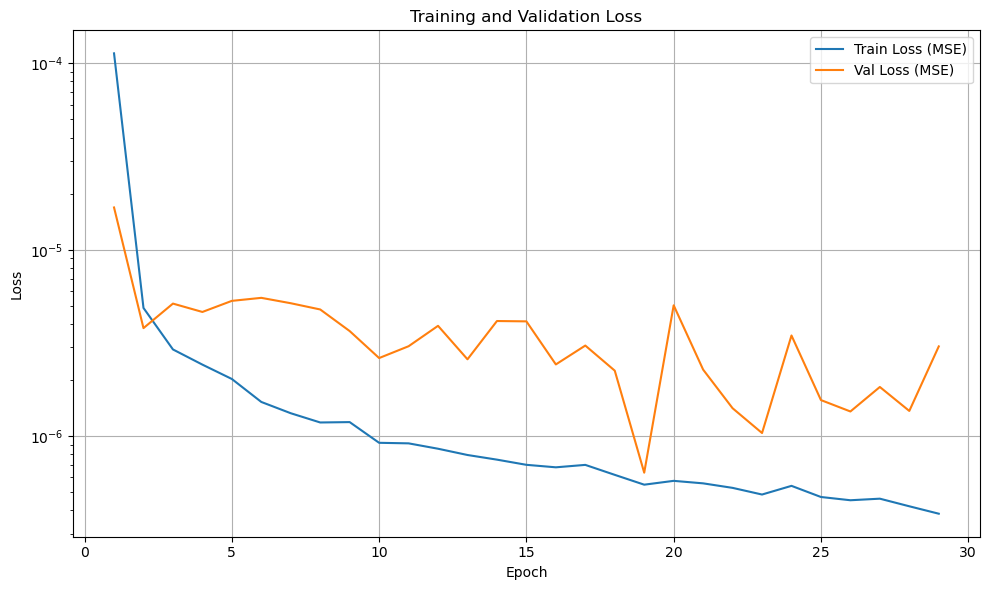

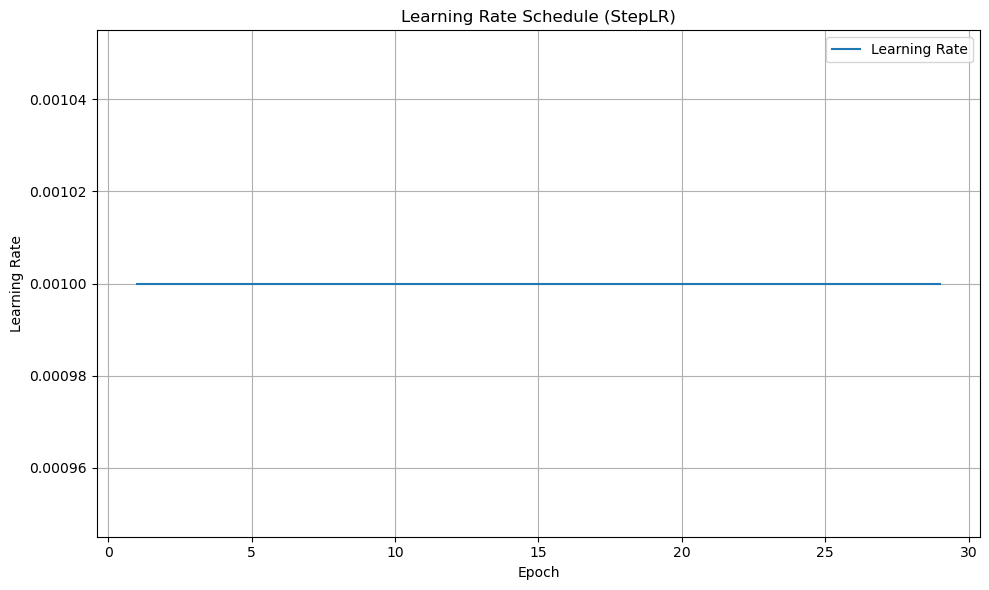

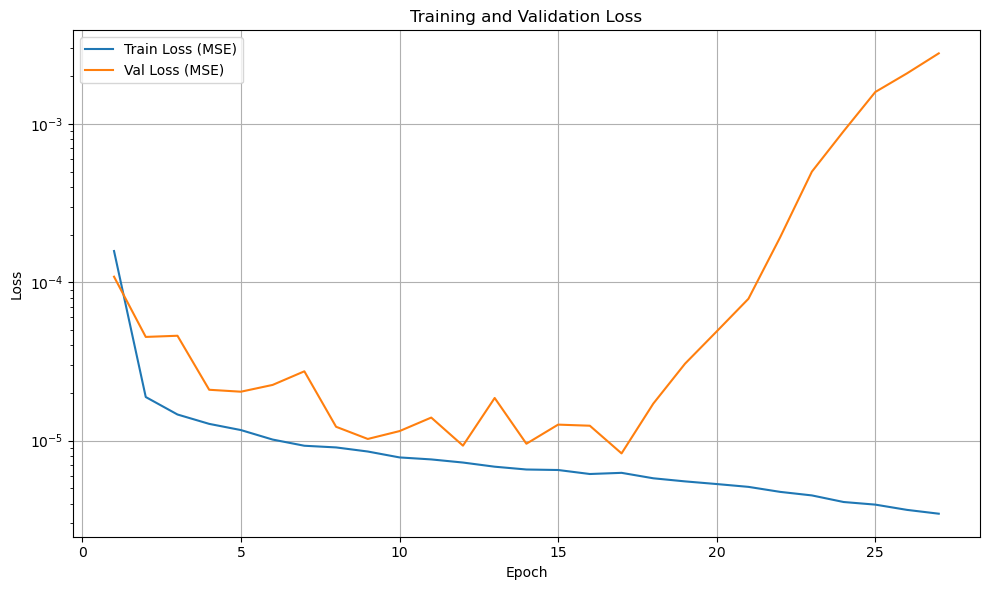

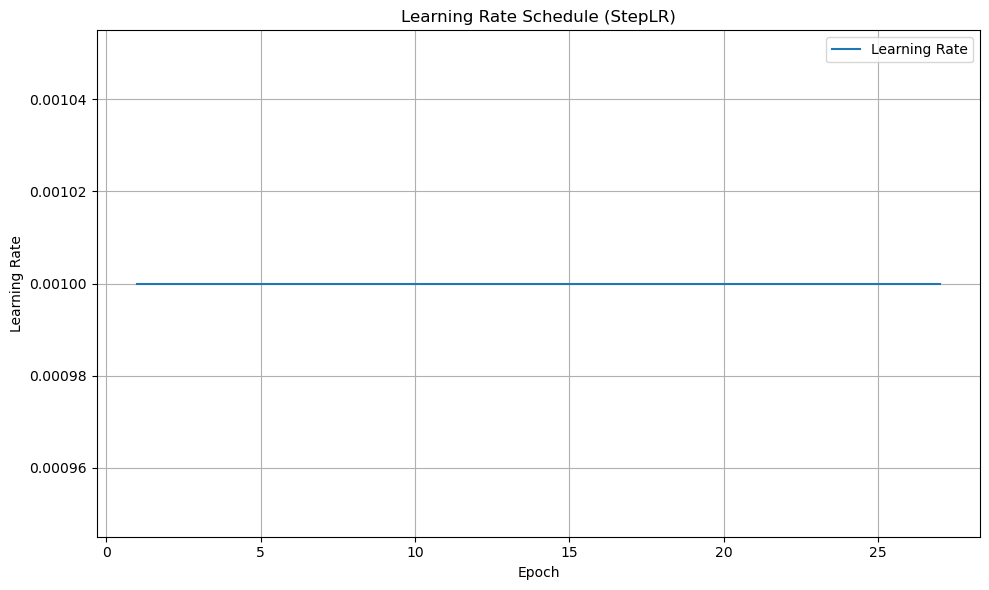

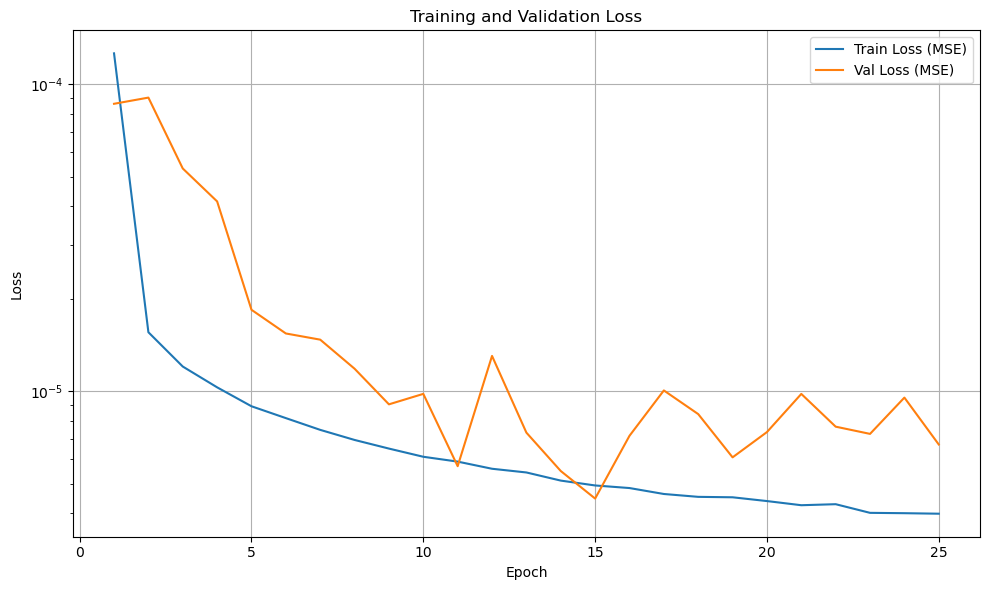

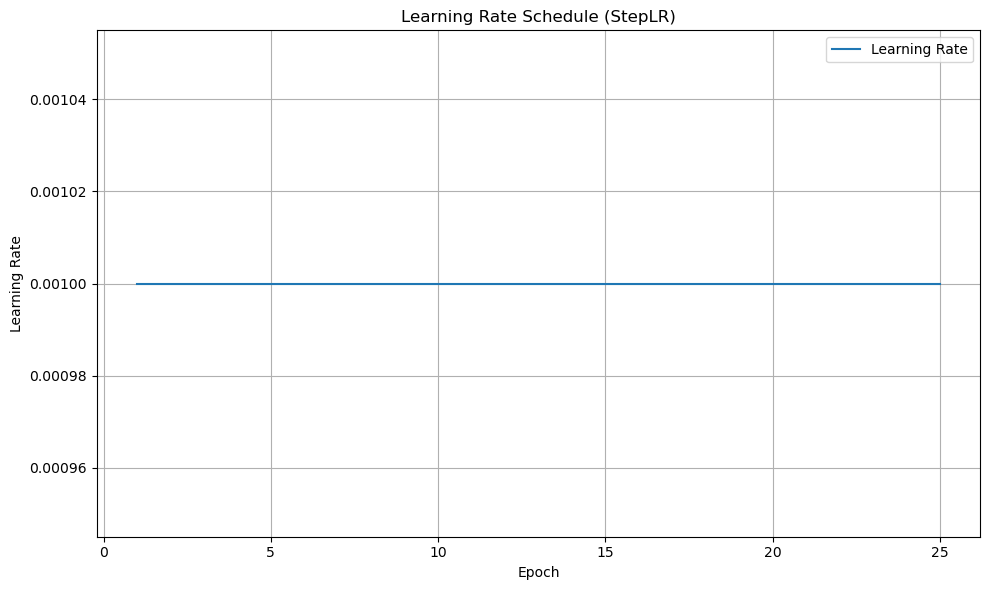

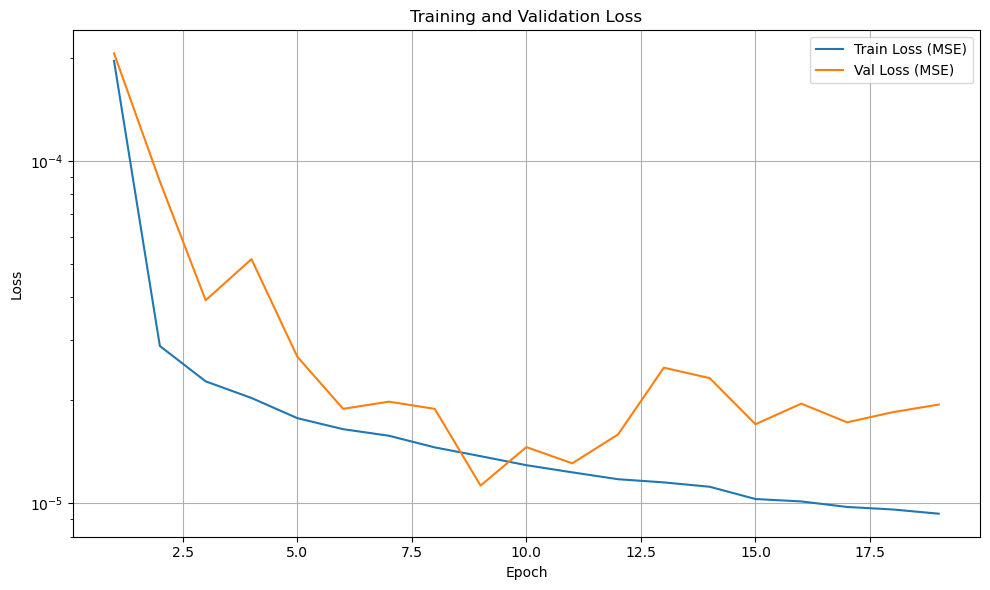

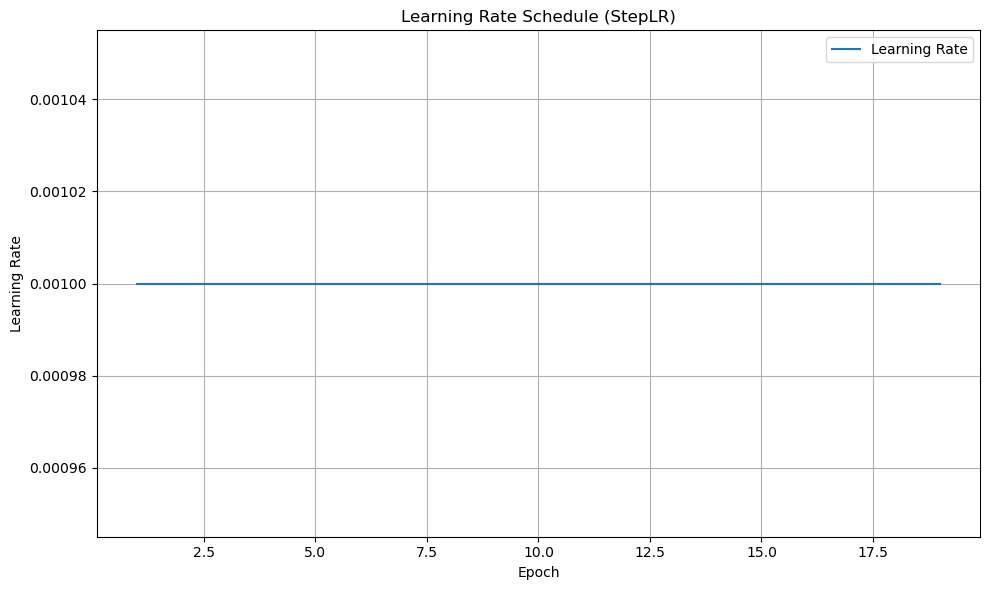

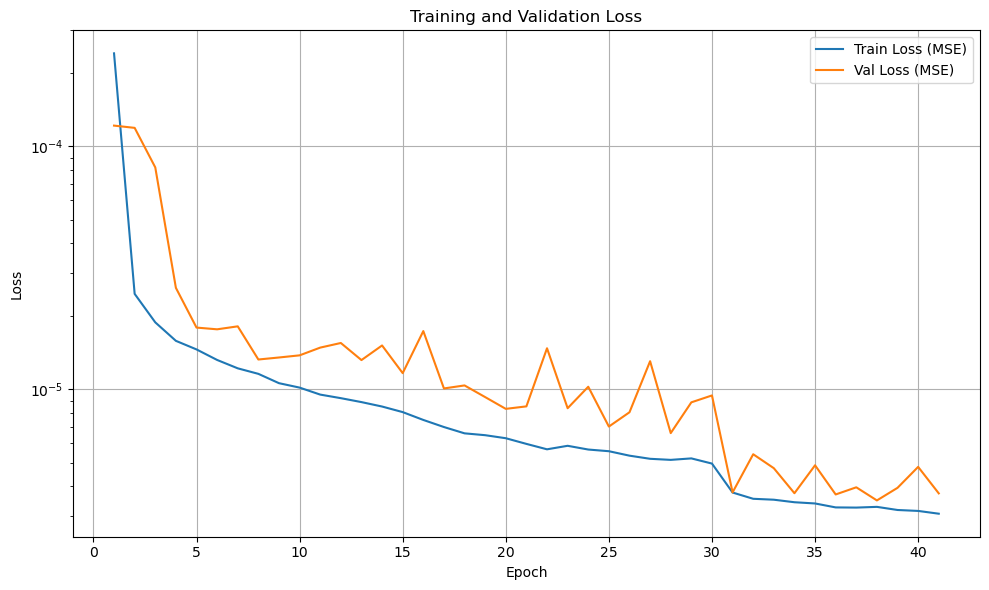

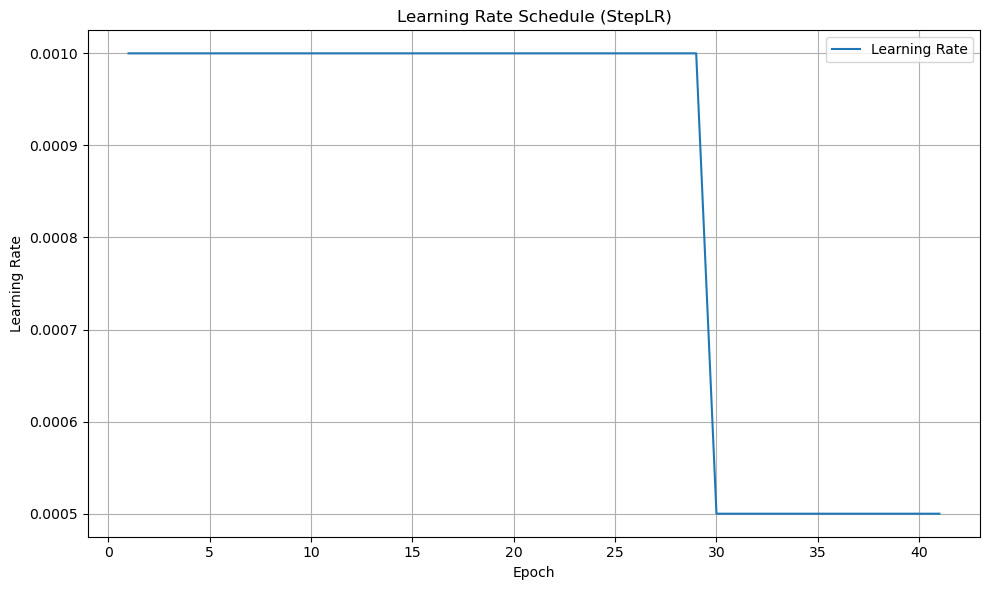

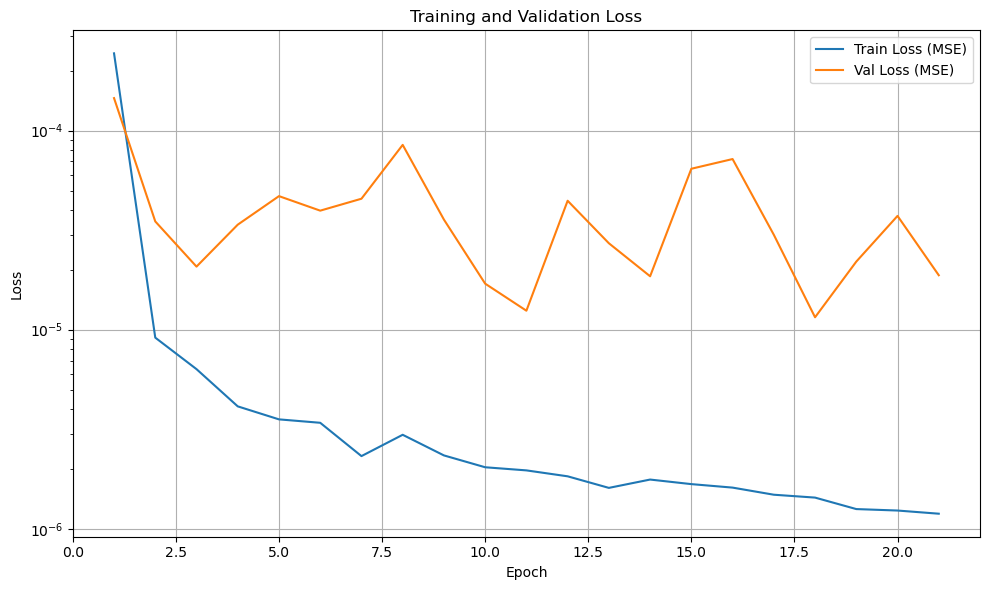

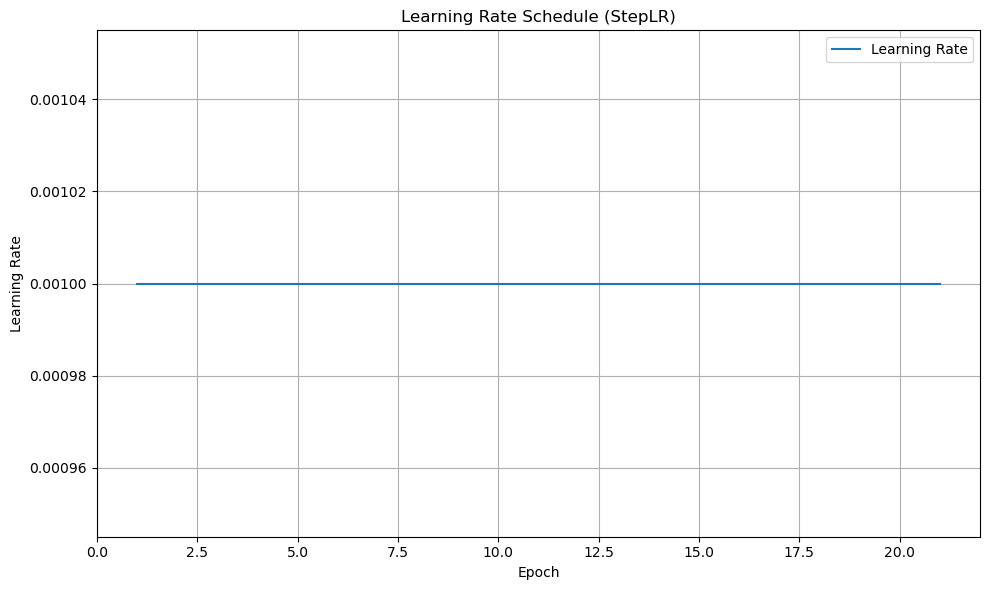

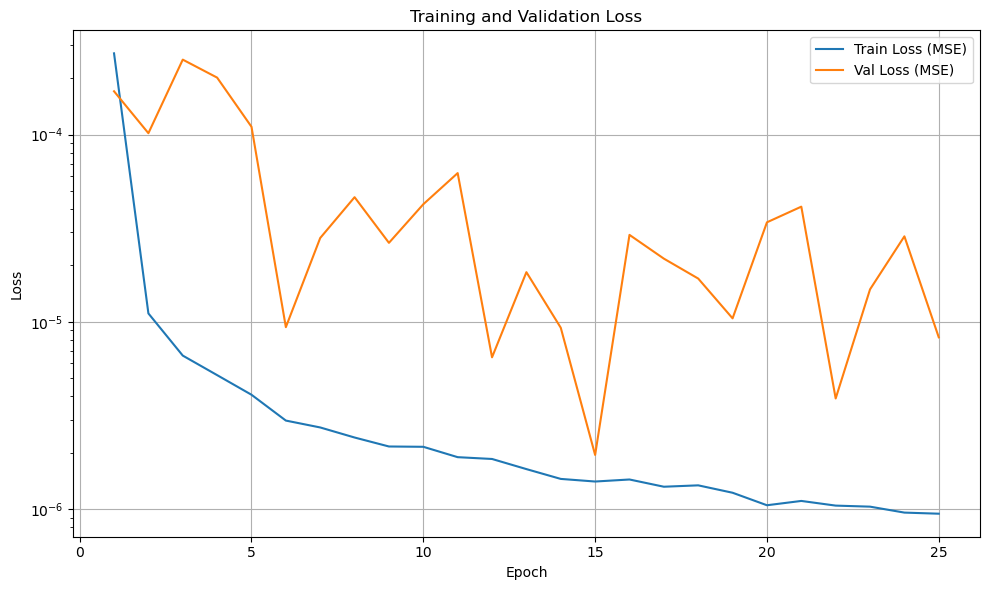

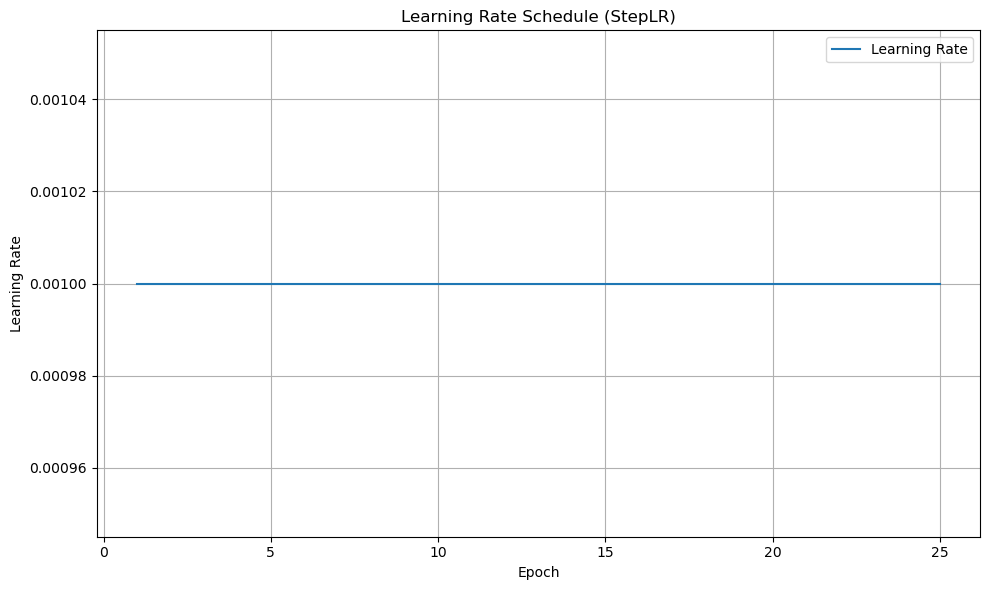

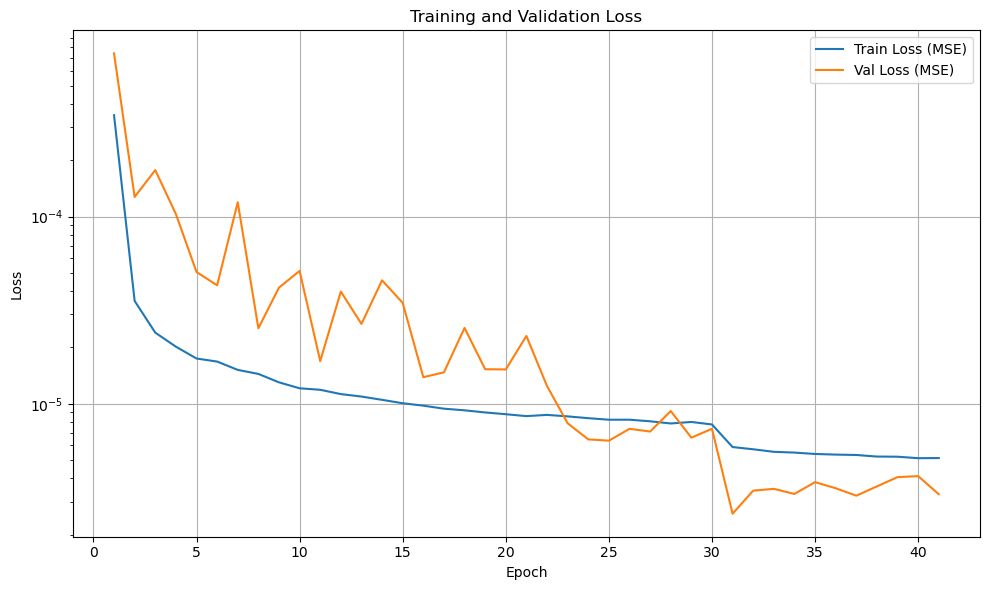

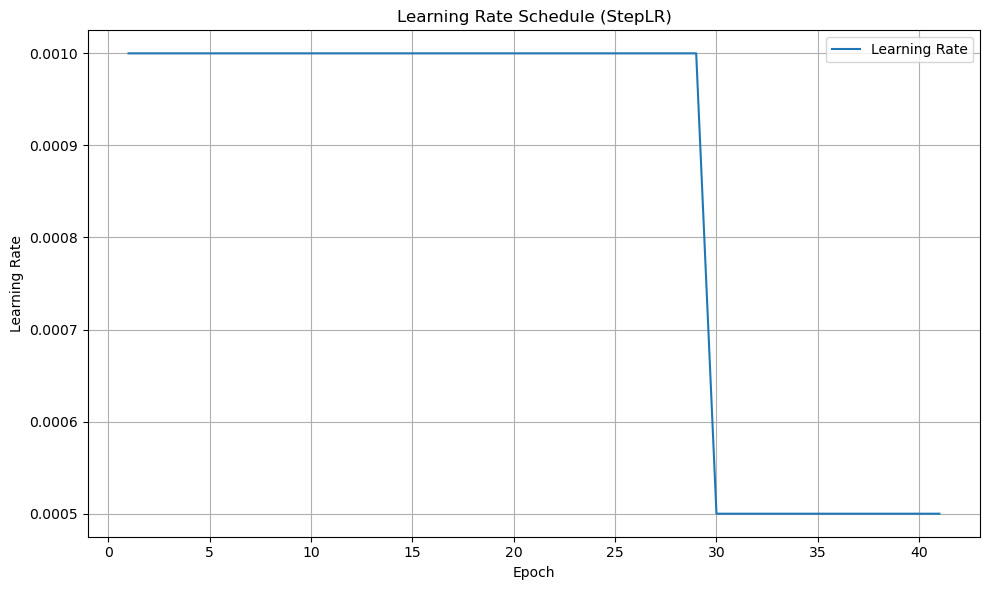

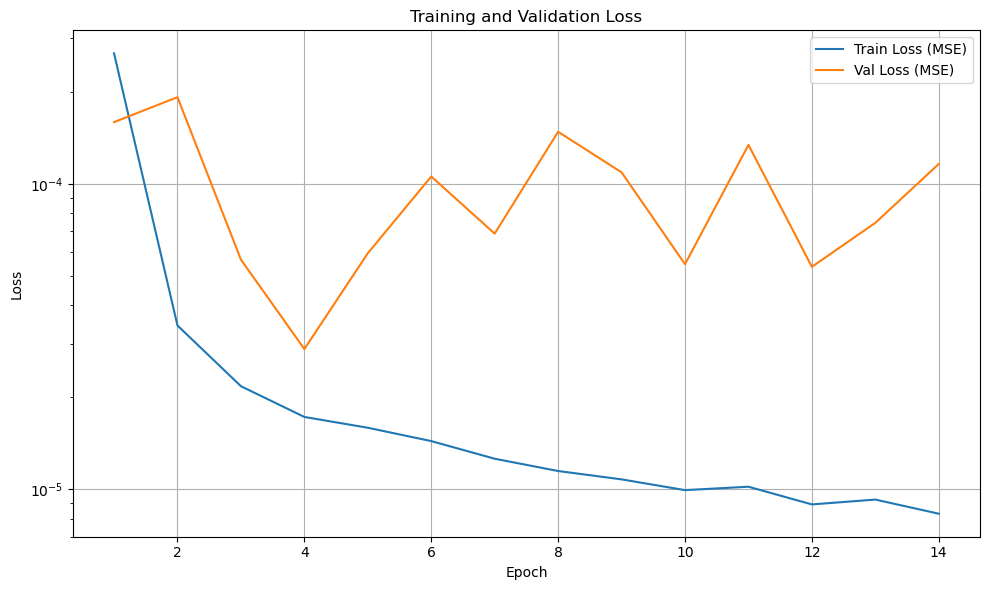

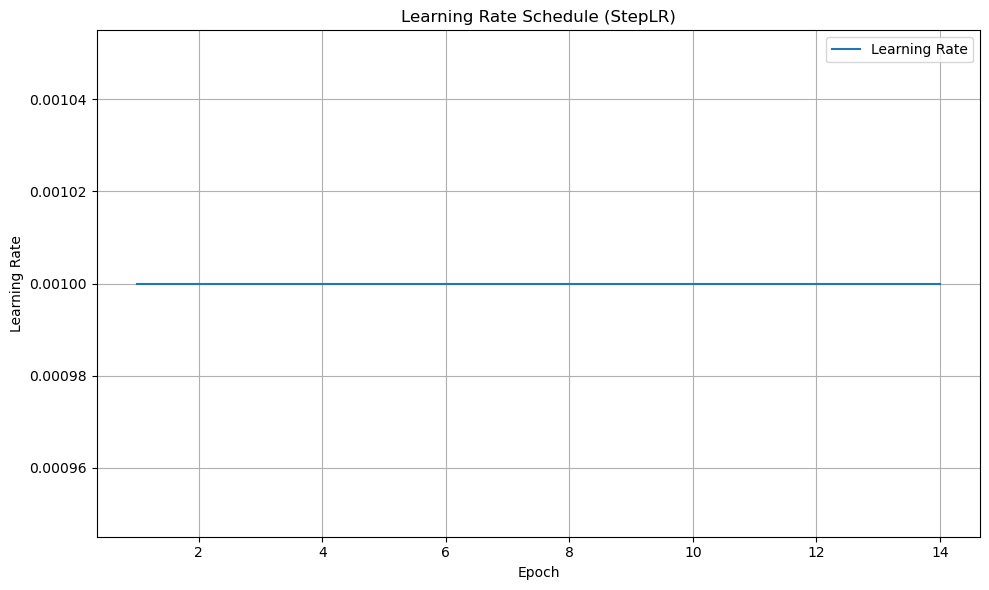

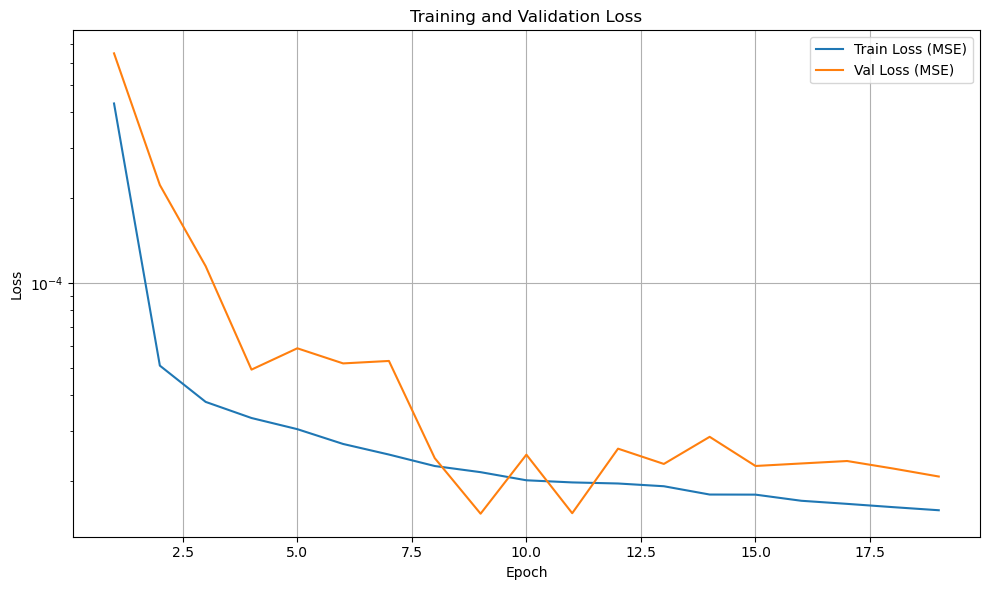

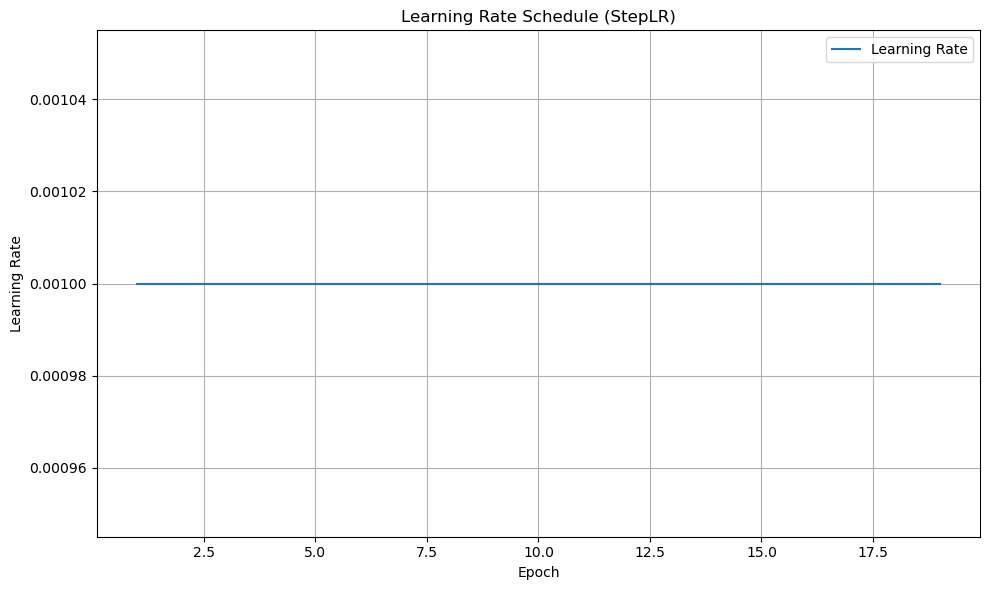

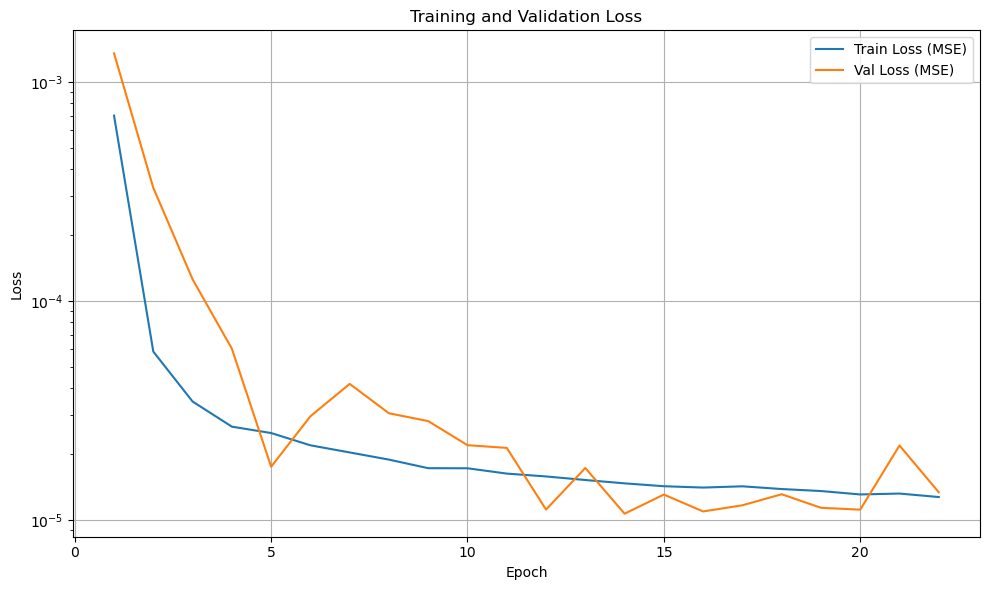

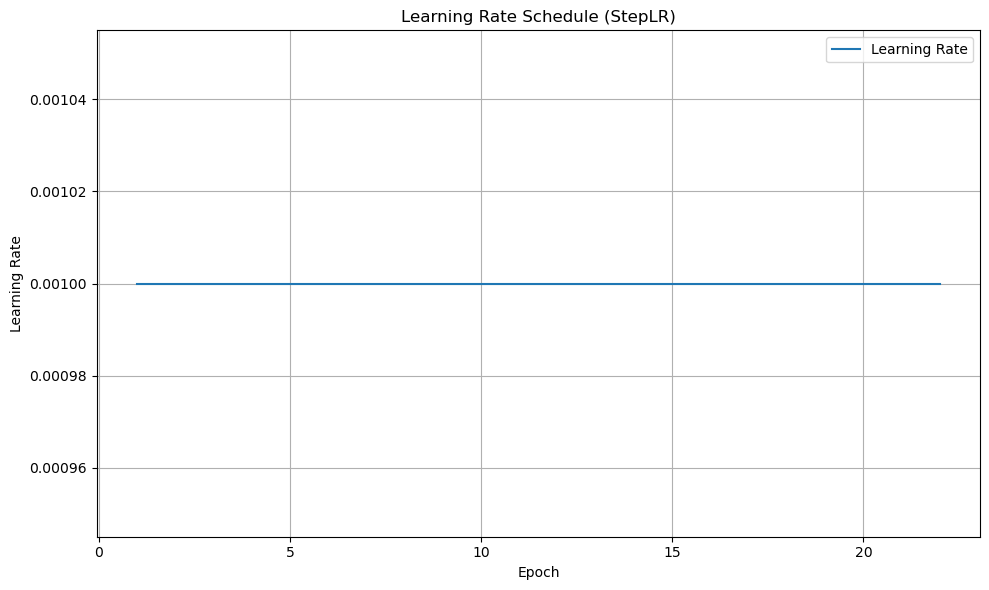

In [9]:
results, best = run_grid_search(config)
print("Best trial:", best)

In [11]:
test_metrics = test_best_model(config, best)
print("Test timing metrics:", test_metrics)

LSTMRegressor architecture:
  Input features: 14
  LSTM layers (1): hidden_size=256, dropout=0.3
  FC layers (1): [256]
  Output targets: 13



Forecast profiles: 300profile [03:15,  1.53profile/s, mae_avg=1.215871e+03]


Testing timing summary: total_fetch: 0.0002s -  total_test: 192.5569s -  avg_fetch_profile: 0.0000s -  avg_inference_profile: 0.6419s -  save_time: 0.1567s

Saved best-model test outputs to: ..\outputs\ml_results\hp_tuning\N2001\tuning_k8\trial_0001_lb8_lr0.0001_bs128_nl1_hl256_hf256\best_model_test
Test timing metrics: {'avg_fetch_profile_s': 6.480010536809763e-07, 'avg_inference_profile_s': 0.6418556696649951, 'total_fetch_s': 0.00019440031610429287, 'total_test_s': 192.55689529981464, 'save_time_s': 0.1566500999033451}


In [13]:
save_forecast_profiles_pdf(
    forecast_h5_path=Path("../outputs/ml_results/hp_tuning/N2001/tuning_k8/trial_0001_lb8_lr0.0001_bs128_nl1_hl256_hf256/best_model_test/rolling_forecasts.h5"),
    output_pdf_path=Path("../outputs/ml_results/hp_tuning/N2001/tuning_k8/trial_0001_lb8_lr0.0001_bs128_nl1_hl256_hf256/best_model_test/rolling_forecasts.pdf"),
)

Plotted 10/300
Plotted 20/300
Plotted 30/300
Plotted 40/300
Plotted 50/300
Plotted 60/300
Plotted 70/300
Plotted 80/300
Plotted 90/300
Plotted 100/300
Plotted 110/300
Plotted 120/300
Plotted 130/300
Plotted 140/300
Plotted 150/300
Plotted 160/300
Plotted 170/300
Plotted 180/300
Plotted 190/300
Plotted 200/300
Plotted 210/300
Plotted 220/300
Plotted 230/300
Plotted 240/300
Plotted 250/300
Plotted 260/300
Plotted 270/300
Plotted 280/300
Plotted 290/300
Plotted 300/300
Saved forecast PDF to: ..\outputs\ml_results\hp_tuning\N2001\tuning_k8\trial_0001_lb8_lr0.0001_bs128_nl1_hl256_hf256\best_model_test\rolling_forecasts.pdf
